In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
import xgboost as xgb

In [ ]:
df = pd.read_csv("Telco Customer Churn.csv")

# Drop customerID (not predictive)
df.drop(columns=["customerID"], inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Convert target to binary
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [ ]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,avg_monthly_spend,contract_risk,num_services,high_value_customer
count,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,0.265370,59.083067,1.309527,3.362914,0.417862
std,0.368612,24.559481,30.090047,2266.771362,0.441561,30.514438,0.833755,2.062031,0.493242
min,0.000000,0.000000,18.250000,18.800000,0.000000,9.183333,0.000000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,401.450000,0.000000,26.225944,1.000000,1.000000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000,61.070387,2.000000,3.000000,0.000000
75%,0.000000,55.000000,89.850000,3794.737500,1.000000,84.877538,2.000000,5.000000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000,118.969863,2.000000,8.000000,1.000000


In [ ]:
df.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


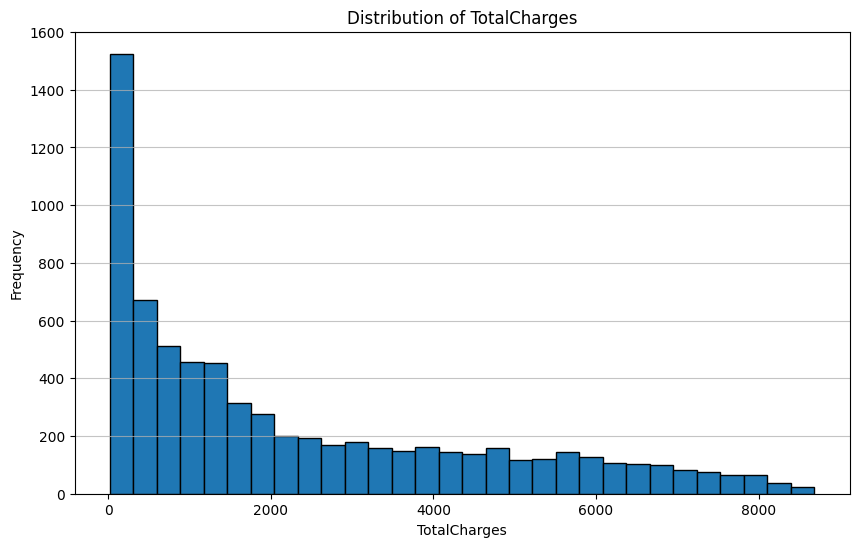

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['TotalCharges'].dropna(), bins=30, edgecolor='black')
# df['TotalCharges'].dropna().plot(kind='kde')
plt.title('Distribution of TotalCharges')
plt.xlabel('TotalCharges')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

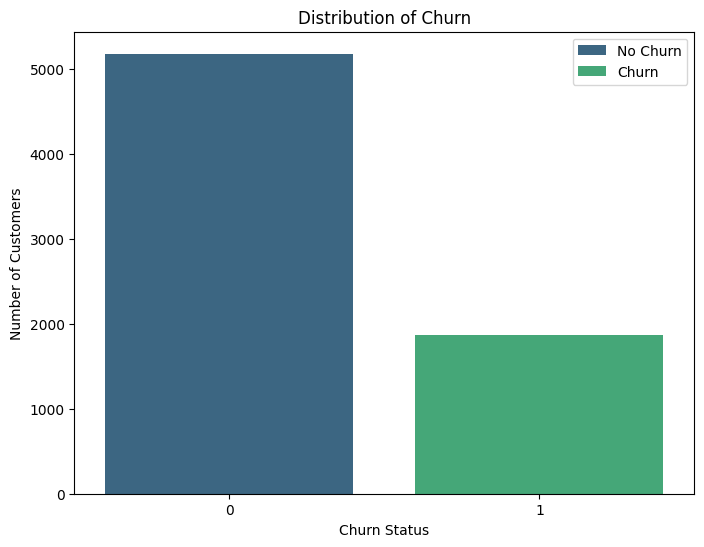

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Churn', data=df, palette='viridis', hue='Churn')
plt.title('Distribution of Churn')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.legend(['No Churn', 'Churn'])
plt.show()

In [ ]:
churn_count = df[df['Churn'] == 1].shape[0]
total_customers = df.shape[0]
percentage_non_churn = (churn_count / total_customers) * 100

print(f"Percentage of customers with Churn == 1: {percentage_non_churn:.2f}%")

Percentage of customers with Churn == 1: 26.54%


Feature Engineering

In [ ]:
# Contract risk score
contract_risk_map = {
    "Month-to-month": 2,
    "One year": 1,
    "Two year": 0
}
df["contract_risk"] = df["Contract"].map(contract_risk_map)

# Engagement score (number of services used)
services = [
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

for col in services:
    df[col] = df[col].replace({"No internet service": "No",
                               "No phone service": "No"})

df["num_services"] = (df[services] == "Yes").sum(axis=1)

# High value customer flag
df["high_value_customer"] = (
    (df["TotalCharges"] > df["TotalCharges"].median()) &
    (df["tenure"] > df["tenure"].median())
).astype(int)

In [ ]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,avg_monthly_spend,contract_risk,num_services,high_value_customer
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,0,14.925000,2,1,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,0,53.985714,1,3,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,1,36.050000,2,3,0
3,Male,0,No,No,45,No,No,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.016304,1,3,1
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,1,50.550000,2,1,0


In [ ]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Preprocessing Pipeline and Handle Imbalance with SMOTE

In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


# Fit preprocessing first to apply SMOTE on numeric array
X_train_processed = preprocessor.fit_transform(X_train)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_processed, y_train)

# Transform test set
X_test_processed = preprocessor.transform(X_test)

In [ ]:
preprocessor_output_features = (
    list(numeric_features) +
    list(preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(categorical_features))
)

X_train_processed_df = pd.DataFrame(X_train_processed, columns=preprocessor_output_features)

display(X_train_processed_df.head())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,avg_monthly_spend,contract_risk,num_services,high_value_customer,gender_Female,gender_Male,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.441773,0.102371,-0.521976,-0.263290,-0.393729,0.827774,-0.184954,1.173548,0.0,1.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-0.441773,-0.711743,0.337478,-0.504815,0.415079,0.827774,-0.667823,-0.852117,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-0.441773,-0.793155,-0.809013,-0.751214,-0.560710,-1.569389,-0.184954,-0.852117,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.441773,-0.263980,0.284384,-0.173700,0.369557,-1.569389,0.780784,-0.852117,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,-0.441773,-1.281624,-0.676279,-0.990851,-1.212006,0.827774,-1.150692,-0.852117,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


Model Training

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=12),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        eval_metric="logloss"
    )
}

fitted_models = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    # model.fit(X_train_processed, y_train)

    # Probability calibration (important for intervention modeling)
    calibrated = CalibratedClassifierCV(model, method="isotonic", cv=3)
    calibrated.fit(X_train_res, y_train_res)
    # calibrated.fit(X_train_processed, y_train)

    fitted_models[name] = calibrated
    print(f"{name} trained and calibrated.")

Logistic Regression trained and calibrated.
Random Forest trained and calibrated.
XGBoost trained and calibrated.


In [ ]:
from sklearn.metrics import classification_report

for name, model in fitted_models.items():
    # Get predictions on the test set
    y_pred = model.predict(X_test_processed)

    print(f"\n--- Classification Report for {name} ---")
    print(classification_report(y_test, y_pred))


--- Classification Report for Logistic Regression ---
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


--- Classification Report for Random Forest ---
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.56      0.66      0.61       374

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409


--- Classification Report for XGBoost ---
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.63      0.55      0.59       374

    accuracy                       

Accuracy for all models decreased after using SMOTE, but the recall for class 1 (customers who churn) increased.
XGBoost was the least model to be affected by using SMOTE

Logistic Regression
  ROC-AUC: 0.846
  PR-AUC : 0.657
Random Forest
  ROC-AUC: 0.836
  PR-AUC : 0.631
XGBoost
  ROC-AUC: 0.835
  PR-AUC : 0.643


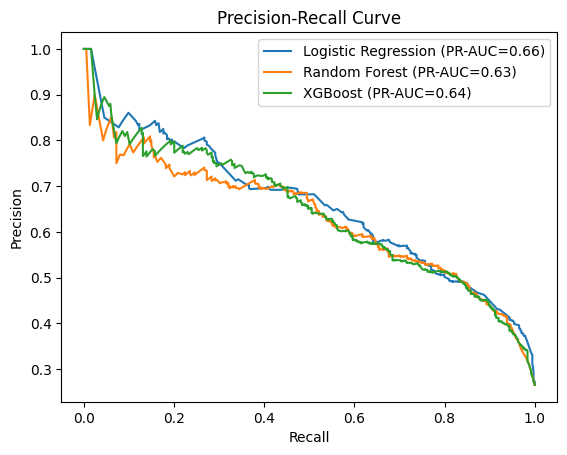

In [ ]:
plt.figure()

for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test_processed)[:, 1]

    roc = roc_auc_score(y_test, y_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)

    print(f"{name}")
    print(f"  ROC-AUC: {roc:.3f}")
    print(f"  PR-AUC : {pr_auc:.3f}")

    plt.plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


SHAP Explainability

In [ ]:
!pip -q install shap

In [ ]:
import shap

# Use XGBoost (best for SHAP)
xgb_model = fitted_models["XGBoost"].estimator

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_processed)


# Calculate mean absolute SHAP values for each feature
mean_abs_shap_values = np.abs(shap_values).mean(axis=0)

# Create a DataFrame to map feature names to their importance
feature_importance_df = pd.DataFrame({
    'Feature': preprocessor_output_features,
    'Mean_Abs_SHAP': mean_abs_shap_values
})

# Sort for better readability
feature_importance_df = feature_importance_df.sort_values(by='Mean_Abs_SHAP', ascending=False)

print("Mapping of Feature Names to Mean Absolute SHAP Importance:")
feature_importance_df.head(10)

Mapping of Feature Names to Mean Absolute SHAP Importance:


,Feature,Mean_Abs_SHAP
5,contract_risk,0.958192
1,tenure,0.483467
19,InternetService_Fiber optic,0.314898
2,MonthlyCharges,0.299107
4,avg_monthly_spend,0.229639
3,TotalCharges,0.222231
40,PaymentMethod_Electronic check,0.181219
21,OnlineSecurity_No,0.128878
36,PaperlessBilling_No,0.116532
27,TechSupport_No,0.105415


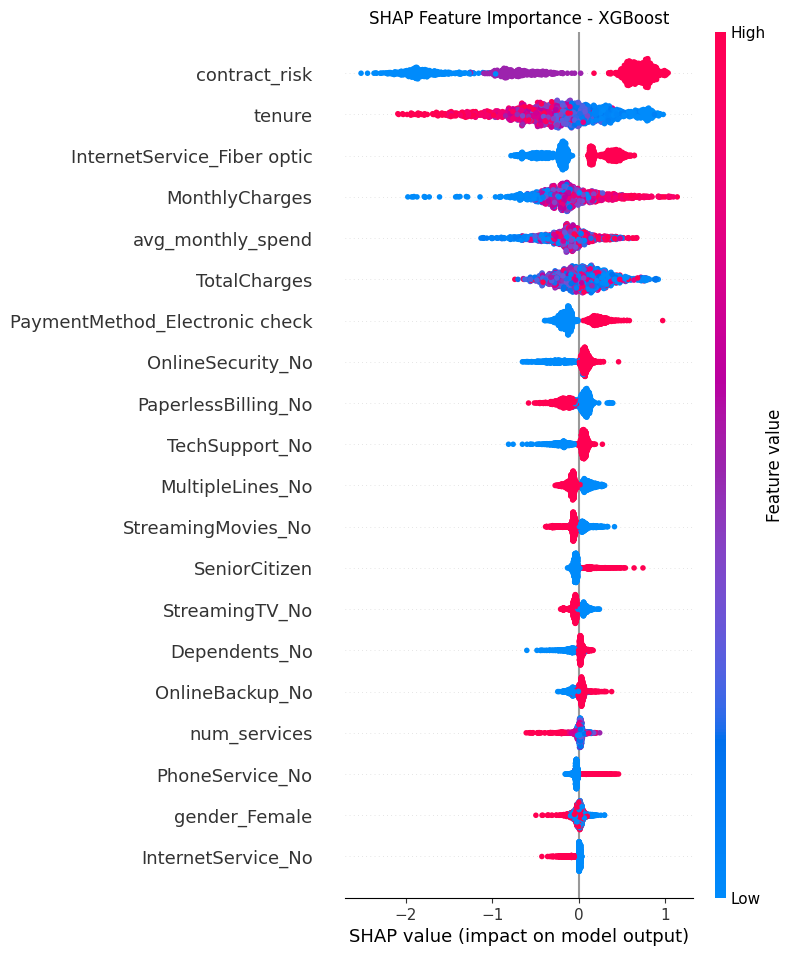

In [ ]:
shap.summary_plot(shap_values, X_test_processed, feature_names=preprocessor_output_features, show=False)
plt.title("SHAP Feature Importance - XGBoost")
plt.show()

Intervention Simulation

In [ ]:
def intervention_simulation(model, X_test, y_test,
                            threshold=0.6,
                            retention_effectiveness=0.4,
                            retention_cost=50,
                            revenue_per_customer=500):
    """
    Simulate retention campaign impact.
    """

    proba = model.predict_proba(X_test)[:, 1]

    targeted = proba >= threshold
    n_targeted = targeted.sum()

    # True churners targeted
    true_churn_targeted = y_test[targeted].sum()

    # Churn prevented
    churn_prevented = true_churn_targeted * retention_effectiveness

    revenue_saved = churn_prevented * revenue_per_customer
    campaign_cost = n_targeted * retention_cost

    net_profit = revenue_saved - campaign_cost

    print("\nIntervention Simulation Results")
    print("--------------------------------")
    print(f"Customers targeted: {n_targeted}")
    print(f"Churn prevented: {int(churn_prevented)}")
    print(f"Revenue saved: ${revenue_saved:,.0f}")
    print(f"Campaign cost: ${campaign_cost:,.0f}")
    print(f"Net profit: ${net_profit:,.0f}")

    return net_profit


best_model = fitted_models["XGBoost"]

intervention_simulation(
    best_model,
    X_test_processed,
    y_test,
    threshold=0.65,
    retention_effectiveness=0.5,
    retention_cost=40,
    revenue_per_customer=600
)


Intervention Simulation Results
--------------------------------
Customers targeted: 215
Churn prevented: 77
Revenue saved: $46,200
Campaign cost: $8,600
Net profit: $37,600


np.float64(37600.0)

Expected Revenue Loss Scoring

In [ ]:
# Use predicted probabilities
y_proba = best_model.predict_proba(X_test_processed)[:, 1]

# Assume customer lifetime value proxy
X_test_copy = X_test.copy()
X_test_copy["churn_probability"] = y_proba

# Revenue proxy
X_test_copy["customer_value"] = X_test_copy["TotalCharges"]

# Expected revenue loss
X_test_copy["expected_revenue_loss"] = (
    X_test_copy["churn_probability"] *
    X_test_copy["customer_value"]
)

# Sort highest financial risk customers
risk_ranked = X_test_copy.sort_values(
    by="expected_revenue_loss",
    ascending=False
)

print(risk_ranked[[
    "churn_probability",
    "customer_value",
    "expected_revenue_loss"
]].head())

      churn_probability  customer_value  expected_revenue_loss
3411           0.893654         5549.40            4959.241351
4572           0.734373         6411.25            4708.247070
7023           0.663148         6479.40            4296.798872
1081           0.838942         4564.90            3829.687385
3910           0.734373         5127.95            3765.826565


Retention Strategy Engine

In [ ]:
def retention_strategy_engine(df,
                              budget=20000,
                              retention_cost=50,
                              retention_success_rate=0.5):
    """
    Select optimal customers under budget constraint.
    """

    df = df.copy()

    df["intervention_cost"] = retention_cost
    df["expected_savings"] = (
        df["expected_revenue_loss"] * retention_success_rate
    )

    df["net_expected_value"] = (
        df["expected_savings"] - df["intervention_cost"]
    )

    # Rank by net expected value
    df = df.sort_values(
        by="net_expected_value",
        ascending=False
    )

    selected = []
    total_cost = 0

    for _, row in df.iterrows():
        if total_cost + retention_cost <= budget:
            selected.append(row)
            total_cost += retention_cost
        else:
            break

    selected_df = pd.DataFrame(selected)

    print("\nRetention Strategy Summary")
    print("--------------------------")
    print(f"Customers selected: {len(selected_df)}")
    print(f"Total campaign cost: ${total_cost:,.0f}")
    print(f"Expected total savings: ${selected_df['expected_savings'].sum():,.0f}")
    print(f"Projected net profit: ${selected_df['net_expected_value'].sum():,.0f}")

    return selected_df


selected_customers = retention_strategy_engine(risk_ranked)


Retention Strategy Summary
--------------------------
Customers selected: 400
Total campaign cost: $20,000
Expected total savings: $216,481
Projected net profit: $196,481
